In [2]:
# project 1st file 기본 전처리 후 모델 돌려보기 2025.11.26
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import importlib
from utils import modeling
importlib.reload(modeling)
from matplotlib import rc
rc('font', family='Malgun Gothic')  # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 깨짐 방지
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

import utils.preprocessing as pp 
import utils.data_sampling as ds 
import utils.user_utils    as uu 
import utils.modeling      as mo

In [3]:
# data loading
df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [4]:
# 기본정보 확인
pp.checkBasicInfo(df, isInfo=False, isGraph=False)

 결측치 정보 ======================================================================
✅ 결측치 없음

== 타겟 분포 ======================================================================

[Class] 개수:
Class
0    284315
1       492
Name: count, dtype: int64

[Class] 비율(%):
  Class 0: 99.83%
  Class 1: 0.17%
  ⚠️ 심각한 불균형 (0.17%)




In [5]:
# df_sacled.head()
## 데이터 
X_features, y_target = pp.split_features_target(df,cols='Time')
X_train, X_test, y_train, y_test = pp.data_split(X_features, y_target)

In [6]:
# GradientBoostingClassifier 기본 파라미터
gb_basic_params = {
    'n_estimators': 100,      # 트리 개수 (더 많을수록 성능↑, 시간↑)
    'learning_rate': 0.1,     # 학습률 (0.01~0.3, 작을수록 안정적)
    'max_depth': 3,           # 개별 트리 깊이 (3~5 권장, 과적합 방지)
    'random_state': 23
}

In [7]:
# DecisionTreeClassifier 기본 파라미터
dt_basic_params = {
    'criterion': 'gini',      # 분할 기준 ('gini' 또는 'entropy')
    'max_depth': None,        # 트리 최대 깊이 (None=제한없음, 과적합 위험)
    'random_state': 23
}

In [8]:
# MLPClassifier 기본 파라미터
mlp_basic_params = {
    'hidden_layer_sizes': (64, 32),  # 은닉층 구조 (64개 노드 → 32개 노드)
    'activation': 'relu',             # 활성화 함수 (relu, tanh, logistic)
    'solver': 'adam',                 # 최적화 알고리즘 (adam, sgd, lbfgs)
    'alpha': 1e-4,                    # L2 정규화 파라미터 (과적합 방지)
    'batch_size': 256,                # 배치 크기 (메모리 허용 범위 내 크게)
    'learning_rate': 'adaptive',      # 학습률 스케줄 (adaptive, constant, invscaling)
    'max_iter': 50,                   # 최대 반복 횟수 (early stopping 권장)
    'random_state': 23
}

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

results_dict = {}

model_name = ' GradientBoosting_notscaled_Timedrop__2025_11_27'
gb_clf = GradientBoostingClassifier(**gb_basic_params)

results_dict['gb'] = uu.get_model_train_eval(gb_clf, model_name, X_train, X_test, y_train, y_test)

✓ 모델 저장 완료: ../models\ GradientBoosting_notscaled_Timedrop__2025_11_27.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.2959, 정확도: 0.9985, 정밀도: 0.7308, 재현율: 0.1939, F1: 0.3065
오차행렬:
[[56857     7]
 [   79    19]]
실행 시간: 323.78143215179443


In [10]:
from sklearn.tree import DecisionTreeClassifier

model_name = ' DecisionTree_notscaled_Timedrop__2025_11_27'
dt_clf = DecisionTreeClassifier(**dt_basic_params)

results_dict['dt'] = uu.get_model_train_eval(dt_clf, model_name, X_train, X_test, y_train, y_test)

✓ 모델 저장 완료: ../models\ DecisionTree_notscaled_Timedrop__2025_11_27.pkl
  파일 크기: 0.03 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.8927, 정확도: 0.9993, 정밀도: 0.7857, 재현율: 0.7857, F1: 0.7857
오차행렬:
[[56843    21]
 [   21    77]]
실행 시간: 19.809898376464844


In [11]:
from sklearn.neural_network import MLPClassifier

model_name = ' MLP_notscaled_Timedrop__2025_11_27'
mlp_clf = MLPClassifier(**mlp_basic_params)

results_dict['mlp'] = uu.get_model_train_eval(mlp_clf, model_name, X_train, X_test, y_train, y_test)

✓ 모델 저장 완료: ../models\ MLP_notscaled_Timedrop__2025_11_27.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9567, 정확도: 0.9996, 정밀도: 0.9310, 재현율: 0.8265, F1: 0.8757
오차행렬:
[[56858     6]
 [   17    81]]
실행 시간: 31.090088605880737


📁 그래프 저장 완료: ..\images\모델별 평가_지표_2025_1127.png


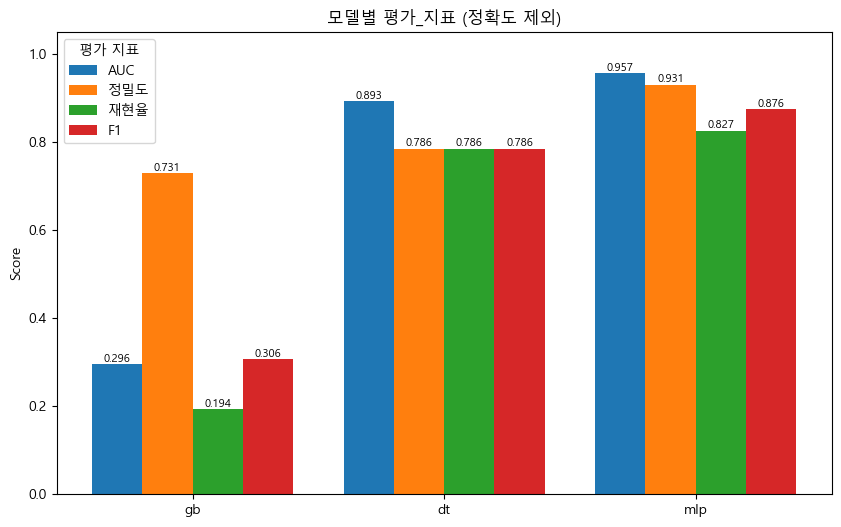

In [ ]:
mo.plot_sampling_metrics(results_dict, title='모델별 평가_지표')